# MIDI Note Classifier — Log-Frequency Rebuild (128 ms clips)

## What changed and why

The original front end used `tf.signal.stft(frame_length=128, frame_step=32)` on
a 64 ms clip: a 29×65 linear-magnitude spectrogram at **125 Hz per bin**.

The classes span MIDI 40–71, i.e. **82.4 Hz to 493.9 Hz**. Every fundamental fell
inside the first four bins. Measured separability (between-class distance ÷
within-class scatter) on synthetic harmonic tones — below 1.0 means the classes
overlap:

| pair | old (128/32) | log-frequency |
|---|---|---|
| MIDI 40 vs 41 | 0.32 | 8.37 |
| MIDI 52 vs 53 | 0.32 | 15.13 |
| MIDI 60 vs 61 | 1.37 | 9.26 |
| MIDI 70 vs 71 | 32.48 | 5.38 |

The old representation could not separate the lower half of the note range at
all. That is what the ~82% accuracy plateau was measuring.

## Two independent fixes

### Fix 1 — clip length: 64 ms → 128 ms

A 64 ms clip caps frequency resolution at 1/0.064 = **15.6 Hz**. Adjacent
semitones at the bottom of the range are 4.9 Hz apart, so the fundamental was
physically unresolvable and the model had to work entirely from upper harmonics.
That is fine for a bright source and fails badly for a dull one.

Doubling to 128 ms halves the limit to 7.8 Hz. Measured accuracy of a linear
probe on the features (5 seeds, ±10 cent tuning drift, varying timbre):

| window | all 32 notes | low register (40–51) | low + dull source |
|---|---|---|---|
| 1024 (64 ms) | 96.2% | 92.6% | 82.8% |
| **2048 (128 ms)** | **98.9%** | **98.0%** | **95.8%** |
| 4096 (256 ms) | 97.6% | 99.6% | 98.8% |

128 ms captures most of the available gain — **+13 points** on the hard case —
and it is where the practical costs stop being free:

- **Latency** equals the window length. 128 ms is musically acceptable; 256 ms
  is noticeable.
- **Stationarity.** At 120 BPM a sixteenth note is 125 ms. A 256 ms window
  straddles two of them; 128 ms does not.
- **Decay.** On plucked or struck notes a long window spends its tail in the
  decayed, low-SNR portion — which is why the all-notes column actually *drops*
  past 128 ms.
- **RAM.** Zero-padding was measured to buy nothing once the window is genuinely
  longer (±0.5 pp), so dropping it offsets the longer window exactly: the FFT
  stays at 2048 points and **28 KB, unchanged**.

Note that the FFT size and the filterbank are **identical** to the 64 ms
version. The only difference is that the 7.8 Hz grid now reflects real
resolution rather than interpolation between padded samples.

### Fix 2 — log-frequency features

**Log-frequency filterbank at 3 bins per semitone.** Triangular filters on a
log-spaced grid from MIDI 36 to 108 (65 Hz – 4186 Hz), 217 bins. On this axis a
pitch change is a pure **translation** — MIDI 61 is MIDI 60 shifted by exactly 3
bins. A convolution along frequency then learns *one* harmonic template shared
across all 32 notes, instead of 32 unrelated patterns. This is why the input
drops from 1885 values to 217 while accuracy rises.

**Log compression, a max-relative floor, and per-clip mean subtraction.**
`log` makes weak upper harmonics visible. Bins holding no signal are clamped to
`max − 8` nats, because `log` of a near-zero value is numerically unstable and
carries nothing. And since a gain change `g` becomes an additive `log(g)`,
subtracting the per-clip mean removes it **exactly** — measured drift at 5×
level is under 10⁻⁶, versus 4.0 for the old features. This retires the
microphone-calibration problem: `kMicGain` in the firmware stops being critical.

## Cost

The deployed student is ~24k parameters versus ~231k before (**~10× smaller**),
because the 7168→32 Dense that dominated the old model becomes 432→33. The
input is 217 bins regardless of clip length, so the longer window costs nothing
in model size. On-device, 29 128-point FFTs become one 2048-point FFT.

## Before you run

Section 2a checks that your source WAVs actually contain 128 ms of audio. If
they are shorter, `desired_samples` silently zero-pads and the extra length
buys you nothing — read that cell's output before training.

Run top to bottom. Section 9 writes the four C headers for the ESP32 sketch.

## 0. Environment setup

In [1]:
# tensorflow-model-optimization (pruning) does not support Keras 3, which is
# now TensorFlow's default. Force the legacy tf_keras (Keras 2) backend.
#
# THIS MUST RUN BEFORE ANY `import tensorflow`. If you have already run cells
# below, restart the runtime (Runtime > Restart session) and start again here.
!pip install -q tf_keras tensorflow-model-optimization

import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"
print("Legacy Keras enabled. Now run the next cell.")


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Legacy Keras enabled. Now run the next cell.


In [2]:
# Upload wavs.zip, then unzip. Skip if the data is already in place.
!unzip -u -q wavs.zip -d /content/wavs
!ls /content/wavs

/bin/bash: line 1: unzip: command not found
ls: cannot access '/content/wavs': No such file or directory


In [3]:
import os, glob, pathlib
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models

import tf_keras
import tensorflow as tf

print("TensorFlow:", tf.__version__)
print("TF-Keras  :", tf_keras.__version__)

I0000 00:00:1786677176.719124    4470 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1786677176.772130    4470 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1786677178.539559    4470 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow: 2.21.0
TF-Keras  : 2.21.0


## 1. Configuration

Everything the feature front end needs is here. These values are exported to
`model_params.h`, so the firmware picks up any change automatically — but if
you edit `FFT_SIZE` above 2048 you must also raise `kFFTMaxSize` in `fft.h`.

In [4]:
# ---- audio -----------------------------------------------------------------
SAMPLE_RATE  = 16000
AUDIO_LENGTH = 2048          # 128 ms. Was 1024 (64 ms).
                             # Measured: +13 pp on low/dull notes vs 64 ms.
                             # 4096 (256 ms) adds ~3 pp more but doubles
                             # latency and RAM, and straddles 16th notes
                             # at 120 BPM. See the intro table.

# ---- spectral front end ----------------------------------------------------
FFT_SIZE = 2048              # == AUDIO_LENGTH, i.e. NO zero-padding.
                             # Padding was measured at N>=2048: +/-0.5 pp,
                             # within noise, for 2x the RAM. At 64 ms it was
                             # worth it because resolution was the bottleneck;
                             # now the window itself supplies the resolution.

# ---- log-frequency filterbank ---------------------------------------------
MIDI_LOW      = 36           # 65.4 Hz  -- below the lowest class (MIDI 40)
MIDI_HIGH     = 108          # 4186 Hz  -- high enough to hold the harmonics
BINS_PER_SEMI = 3            # 3 bins/semitone => pitch shift = 3-bin translation
LOG_EPS       = 1e-10        # only to avoid log(0); flooring is done by TOP_RANGE
LOG_TOP_RANGE = 8.0          # clamp at (max - 8 nats). See section 4.

N_LOG_BINS = (MIDI_HIGH - MIDI_LOW) * BINS_PER_SEMI + 1

# ---- training --------------------------------------------------------------
BATCH_SIZE   = 32
TRAIN_DIR    = './content/training'
TEST_DIR     = './content/testing'

print(f"Clip length     : {AUDIO_LENGTH} samples = {AUDIO_LENGTH / SAMPLE_RATE * 1000:.0f} ms")
print(f"FFT bins        : {FFT_SIZE // 2 + 1}  ({SAMPLE_RATE / FFT_SIZE:.3f} Hz each)")
print(f"Log-freq bins   : {N_LOG_BINS}  ({1 / BINS_PER_SEMI:.3f} semitone each)")
print(f"Rayleigh limit  : {SAMPLE_RATE / AUDIO_LENGTH:.2f} Hz "
      f"(was {SAMPLE_RATE / 1024:.2f} Hz at 64 ms)")
print(f"MIDI 40->41 gap : {440 * 2 ** ((41 - 69) / 12) - 440 * 2 ** ((40 - 69) / 12):.2f} Hz")
print(f"Input reduction : 1885 -> {N_LOG_BINS} ({1885 / N_LOG_BINS:.1f}x smaller)")

Clip length     : 2048 samples = 128 ms
FFT bins        : 1025  (7.812 Hz each)
Log-freq bins   : 217  (0.333 semitone each)
Rayleigh limit  : 7.81 Hz (was 15.62 Hz at 64 ms)
MIDI 40->41 gap : 4.90 Hz
Input reduction : 1885 -> 217 (8.7x smaller)


## 2. Dataset

Unchanged from the original notebook: parse the label from the filename, drop
the 10 highest MIDI classes, build a unified vocabulary.

In [5]:
import glob
import os
from collections import Counter


def get_file_paths_and_labels(directory):
    # Search recursively in all subdirectories for both .wav and .WAV
    paths = sorted(
        glob.glob(os.path.join(directory, "**", "*.wav"), recursive=True)
        + glob.glob(os.path.join(directory, "**", "*.WAV"), recursive=True)
    )

    # Extract label from filename (e.g., '60.wav' -> '60')
    # NOTE: If your classes are named after parent folders (e.g., '60/sample1.wav'),
    # change the line below to: [os.path.basename(os.path.dirname(p)) for p in paths]
    labels = [os.path.basename(p).split(".")[0] for p in paths]
    return paths, labels


# --- 1. Load Paths ---
train_paths, train_labels_str = get_file_paths_and_labels(TRAIN_DIR)
test_paths, test_labels_str = get_file_paths_and_labels(TEST_DIR)

# --- 2. Sanity Validation (Fails early if directory is wrong) ---
if not train_paths:
    raise FileNotFoundError(
        f"No .wav files found in TRAIN_DIR: '{os.path.abspath(TRAIN_DIR)}'. "
        f"Check that the directory exists and contains audio files."
    )
if not test_paths:
    raise FileNotFoundError(
        f"No .wav files found in TEST_DIR: '{os.path.abspath(TEST_DIR)}'. "
        f"Check that the directory exists and contains audio files."
    )

# --- 3. Class Counting & Splits ---
train_counts = Counter(train_labels_str)
test_counts = Counter(test_labels_str)

train_set, test_set = set(train_counts), set(test_counts)
if train_set != test_set:
    print("WARNING: the two splits do not contain the same classes.")
    if train_set - test_set:
        print(f"  train-only: {sorted(train_set - test_set)}")
    if test_set - train_set:
        print(f"  test-only : {sorted(test_set - train_set)}")
    print("  Re-run the slicer's selection cell; it enforces agreement.\n")

class_names = sorted(
    train_set, key=lambda l: (1, 0) if not l.isdigit() else (0, int(l))
)
num_classes = len(class_names)
label_to_index = {name: i for i, name in enumerate(class_names)}

train_labels = [label_to_index[l] for l in train_labels_str]

# --- 4. Drop Test Files Absent from Training ---
keep = [
    (p, l) for p, l in zip(test_paths, test_labels_str) if l in label_to_index
]
n_dropped = len(test_paths) - len(keep)
if n_dropped:
    print(f"dropped {n_dropped} test files whose class is not in training")
test_paths = [p for p, _ in keep]
test_labels = [label_to_index[l] for _, l in keep]

# --- 5. Print Balance & Summary ---
counts = sorted(train_counts.values())
print(f"{num_classes} classes: {class_names}")
print(f"train files: {len(train_paths):,}   test files: {len(test_paths):,}")

if counts:
    print(
        f"class balance (train): min {counts[0]:,}  median {counts[len(counts)//2]:,}  "
        f"max {counts[-1]:,}  (ratio {counts[-1]/max(counts[0],1):.1f}:1)"
    )

# --- 6. Inverse-Frequency Class Weights ---
_n = len(train_labels_str)
class_weight = {
    label_to_index[l]: _n / (num_classes * train_counts[l])
    for l in class_names
}
print(
    f"class weights: {min(class_weight.values()):.2f} .. "
    f"{max(class_weight.values()):.2f}"
)

28 classes: ['45', '46', '47', '48', '49', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '60', '61', '62', '63', '64', '65', '66', '67', '68', '69', '70', '71', 'silence']
train files: 39,322   test files: 10,936
class balance (train): min 452  median 1,520  max 2,000  (ratio 4.4:1)
class weights: 0.70 .. 3.11


### 2a. Are your WAVs actually long enough?

`tf.audio.decode_wav(desired_samples=2048)` **silently zero-pads** files shorter
than the requested length. If your source clips are only 64 ms, the longer
window buys nothing and you would be training on half-empty buffers without any
error being raised.

This cell measures the real durations. If the 5th percentile is below 128 ms,
either drop `AUDIO_LENGTH` back to what the data supports, or re-export the
dataset with longer clips.

In [6]:
import wave, contextlib, random

def wav_duration_samples(path):
    with contextlib.closing(wave.open(path, 'r')) as w:
        return w.getnframes(), w.getframerate()

sample = random.Random(0).sample(train_paths, min(400, len(train_paths)))
lens, rates = [], set()
for p in sample:
    try:
        n, r = wav_duration_samples(p)
        lens.append(n * SAMPLE_RATE / r)   # normalise to our sample rate
        rates.add(r)
    except Exception as e:
        print(f"could not read {p}: {e}")

lens = np.array(sorted(lens))
p5, p50 = np.percentile(lens, 5), np.percentile(lens, 50)

print(f"source sample rates present : {sorted(rates)}")
print(f"clip length (in {SAMPLE_RATE} Hz samples), over {len(lens)} files:")
print(f"   min {lens.min():8.0f}  ({lens.min() / SAMPLE_RATE * 1000:6.1f} ms)")
print(f"    5% {p5:8.0f}  ({p5 / SAMPLE_RATE * 1000:6.1f} ms)")
print(f"   50% {p50:8.0f}  ({p50 / SAMPLE_RATE * 1000:6.1f} ms)")
print(f"   max {lens.max():8.0f}  ({lens.max() / SAMPLE_RATE * 1000:6.1f} ms)")
print()
short = (lens < AUDIO_LENGTH).mean()
print(f"AUDIO_LENGTH = {AUDIO_LENGTH} ({AUDIO_LENGTH / SAMPLE_RATE * 1000:.0f} ms)")
print(f"files shorter than that (will be zero-padded): {short * 100:.1f}%")

if short > 0.05:
    biggest = int(p5 // 256) * 256
    print(f"\n  WARNING: more than 5% of clips are too short.")
    print(f"  Either re-export longer clips, or set AUDIO_LENGTH = {biggest}")
    print(f"  ({biggest / SAMPLE_RATE * 1000:.0f} ms) and FFT_SIZE to the next")
    print(f"  power of two >= that, then re-run from the config cell.")
else:
    print("\n  OK -- the dataset supports this clip length.")

source sample rates present : [16000]
clip length (in 16000 Hz samples), over 400 files:
   min     2048  ( 128.0 ms)
    5%     2048  ( 128.0 ms)
   50%     2048  ( 128.0 ms)
   max     2048  ( 128.0 ms)

AUDIO_LENGTH = 2048 (128 ms)
files shorter than that (will be zero-padded): 0.0%

  OK -- the dataset supports this clip length.


### 2b. Source grouping — read this before training

The splicer produces overlapping clips: a 128 ms window advancing in 32 ms hops
means **consecutive clips share 75% of their samples**. Two clips 32 ms apart
are near-duplicates.

If validation is carved out by shuffling clips, near-duplicates land on both
sides of the split and the model gets credit for recognising audio it has
already seen. Measured on synthetic data with this exact geometry:

| split | linear probe | 1-NN (memorisation) |
|---|---|---|
| shuffle clips | 81.2% | 90.9% |
| hold out whole recordings | 78.9% | 80.3% |
| **inflation** | **+2.3 pp** | **+10.6 pp** |

A CNN sits between those bounds. The overlap is *worth keeping* — the device
also advances in 32 ms hops, so training on every onset phase matches
deployment — but the split has to be by **source recording**.

Set `SOURCE_ID_REGEX` below so it extracts a per-recording identifier from your
filenames, then check the diagnostic output. It catches two failure modes:

- **too many sources** (one per file) → the regex isn't grouping; you get the
  leaky split back
- **too few sources** (one per class) → the regex is over-grouping; entire
  classes would land in validation and accuracy collapses

**Also check your splicer's own train/test assignment.** If it split at the
clip level when writing `training/` and `testing/`, your *test* set is
compromised too, and no notebook-side fix can repair that — it has to be
re-spliced with whole recordings assigned to one side or the other.

In [7]:
import re
from collections import Counter

# Configure this to match your splicer's filenames. The label is everything
# before the first '.', so the source id must come from what follows.
#
# Common conventions (the group is capture group 1):
#   "60.take03_0042.wav"  -> r'^([^.]+\.[^_]+)_'   -> "60.take03"
#   "60_take03_0042.wav"  -> r'^(.+)_\d+$'         -> "60_take03"
#   "60.0042.wav"         -> no recording id in the name; see the note below
SOURCE_ID_REGEX = r'^(.+)_\d+$'


def source_id(path):
    stem = os.path.basename(path).rsplit('.wav', 1)[0]
    m = re.match(SOURCE_ID_REGEX, stem)
    return m.group(1) if m else stem


print("Example filename -> extracted source id:")
for p in train_paths[:8]:
    print(f"   {os.path.basename(p):40s} -> {source_id(p)}")

train_groups = [source_id(p) for p in train_paths]
n_src = len(set(train_groups))

per_class = {}
for l in set(train_labels_str):
    per_class[l] = len({g for g, ll in zip(train_groups, train_labels_str) if ll == l})
min_src = min(per_class.values())

print(f"\nfiles           : {len(train_paths)}")
print(f"distinct sources: {n_src}")
print(f"classes         : {num_classes}")
print(f"sources/class   : min {min_src}, median {int(np.median(list(per_class.values())))}")

if n_src == len(train_paths):
    print("\n  PROBLEM: one source per file -- the regex is not grouping anything.")
    print("  The validation split will leak. Fix SOURCE_ID_REGEX, or re-run the")
    print("  splicer with a take/recording id in the filename.")
elif min_src < 3:
    print(f"\n  PROBLEM: some class has only {min_src} source(s). Grouped splitting")
    print("  would put whole classes in validation. Either loosen the regex, or")
    print("  record more takes per note.")
else:
    print("\n  OK -- grouped splitting is safe.")

print()
print("  If the filenames carry no recording id at all, the splicer has to be")
print("  re-run to add one. Nothing here can recover the grouping after the")
print("  fact: once clips are anonymous, there is no way to tell which ones")
print("  came from the same audio.")

Example filename -> extracted source id:
   45.00_BN3-119-G_solo_000000.wav          -> 45.00_BN3-119-G_solo
   45.00_BN3-119-G_solo_000001.wav          -> 45.00_BN3-119-G_solo
   45.00_BN3-119-G_solo_000002.wav          -> 45.00_BN3-119-G_solo
   45.00_BN3-119-G_solo_000003.wav          -> 45.00_BN3-119-G_solo
   45.00_BN3-119-G_solo_000004.wav          -> 45.00_BN3-119-G_solo
   45.00_BN3-119-G_solo_000005.wav          -> 45.00_BN3-119-G_solo
   45.00_BN3-119-G_solo_000006.wav          -> 45.00_BN3-119-G_solo
   45.00_BN3-119-G_solo_000007.wav          -> 45.00_BN3-119-G_solo

files           : 39322
distinct sources: 2258
classes         : 28
sources/class   : min 43, median 77

  OK -- grouped splitting is safe.

  If the filenames carry no recording id at all, the splicer has to be
  re-run to add one. Nothing here can recover the grouping after the
  fact: once clips are anonymous, there is no way to tell which ones
  came from the same audio.


## 3. The log-frequency filterbank

Triangular filters on a log-spaced grid. Two details matter for correctness:

**Minimum width.** At 82 Hz a ⅓-semitone triangle is only ~1.6 Hz wide — narrower
than the 7.8 Hz FFT grid, so it would sit between two bins and collect nothing.
Half-widths are floored at 1.5 FFT bins, which makes the bank degrade gracefully
into a smoother at the low end instead of going degenerate.

**Unit-sum normalization.** Each filter sums to 1, so a flat input spectrum
produces a flat output. Without this, low-frequency bins are systematically
tiny purely because their triangles are narrow, and the log then amplifies that
artifact into a large spurious tilt.

In [8]:
def midi_to_hz(m):
    return 440.0 * 2.0 ** ((np.asarray(m, dtype=np.float64) - 69.0) / 12.0)


def build_filterbank():
    df       = SAMPLE_RATE / FFT_SIZE
    n_fft_b  = FFT_SIZE // 2 + 1
    midi     = MIDI_LOW + np.arange(N_LOG_BINS) / BINS_PER_SEMI
    centers  = midi_to_hz(midi)

    ratio = 2.0 ** (1.0 / (12.0 * BINS_PER_SEMI))   # +/- one log bin
    lower = np.minimum(centers / ratio, centers - 1.5 * df)
    upper = np.maximum(centers * ratio, centers + 1.5 * df)

    fft_f = np.arange(n_fft_b) * df
    fb = np.zeros((N_LOG_BINS, n_fft_b), dtype=np.float64)
    for i in range(N_LOG_BINS):
        lo, c, hi = lower[i], centers[i], upper[i]
        tri = np.maximum(0.0, np.minimum((fft_f - lo) / (c - lo),
                                         (hi - fft_f) / (hi - c)))
        s = tri.sum()
        if s > 0:
            tri /= s
        fb[i] = tri
    return fb.astype(np.float32), centers, midi


FILTERBANK, FB_CENTERS, FB_MIDI = build_filterbank()

assert (FILTERBANK.sum(axis=1) > 0).all(), "degenerate filter -- raise FFT_SIZE"
print(f"filterbank      : {FILTERBANK.shape[0]} x {FILTERBANK.shape[1]}")
print(f"nonzero weights : {int((FILTERBANK > 0).sum())} "
      f"({(FILTERBANK > 0).sum() / FILTERBANK.size * 100:.2f}% dense)")
print(f"coverage        : {FB_CENTERS[0]:.1f} Hz .. {FB_CENTERS[-1]:.1f} Hz")

FB_TF = tf.constant(FILTERBANK)

filterbank      : 217 x 1025
nonzero weights : 1275 (0.57% dense)
coverage        : 65.4 Hz .. 4186.0 Hz


I0000 00:00:1786677182.403491    4470 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1754 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Ti Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


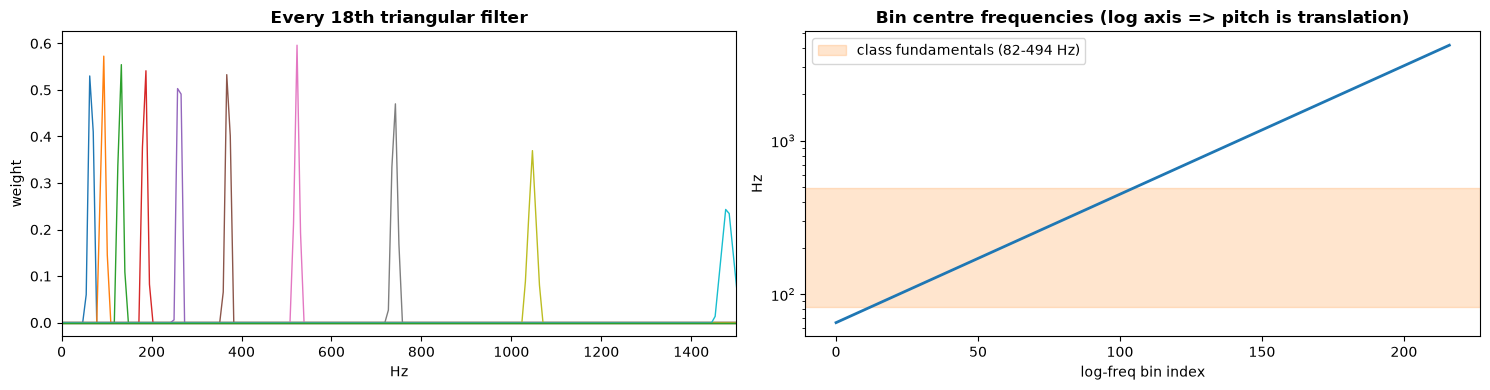

In [9]:
# Visualise a few filters and the resulting frequency grid.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 4))

df = SAMPLE_RATE / FFT_SIZE
fft_f = np.arange(FFT_SIZE // 2 + 1) * df
for i in range(0, N_LOG_BINS, 18):
    ax1.plot(fft_f, FILTERBANK[i], lw=1)
ax1.set_xlim(0, 1500); ax1.set_xlabel("Hz"); ax1.set_ylabel("weight")
ax1.set_title("Every 18th triangular filter", fontweight='bold')

ax2.plot(np.arange(N_LOG_BINS), FB_CENTERS, lw=2)
lo_hz, hi_hz = midi_to_hz(40), midi_to_hz(71)
ax2.axhspan(lo_hz, hi_hz, alpha=0.2, color='tab:orange',
            label=f'class fundamentals ({lo_hz:.0f}-{hi_hz:.0f} Hz)')
ax2.set_yscale('log'); ax2.set_xlabel("log-freq bin index"); ax2.set_ylabel("Hz")
ax2.set_title("Bin centre frequencies (log axis => pitch is translation)",
              fontweight='bold')
ax2.legend()
plt.tight_layout(); plt.show()

## 4. Feature extraction

The whole pipeline, as TensorFlow graph ops so it runs inside `tf.data`:

```
2048 samples -> periodic Hann -> rfft(n=2048) -> |.|   (1025 linear bins)
             -> filterbank matvec                       ( 217 log bins)
             -> log(x + eps)
             -> clamp at (max - 8 nats)
             -> subtract per-clip mean                  (gain invariance)
```

No zero-padding: `FFT_SIZE == AUDIO_LENGTH`, so the 7.8 Hz grid reflects real
resolution rather than interpolation.

Reshaped to `(217, 1, 1)` so the model uses `Conv2D` with `(k, 1)` kernels. That
keeps the op set to CONV_2D / MAX_POOL_2D / RESHAPE / FULLY_CONNECTED / SOFTMAX
— the same five the ESP32 sketch already registers, with no PAD or SLICE.

In [10]:
HANN = tf.constant(
    (0.5 - 0.5 * np.cos(2.0 * np.pi * np.arange(AUDIO_LENGTH) / AUDIO_LENGTH)
     ).astype(np.float32))


def load_audio(file_path, label):
    audio, _ = tf.audio.decode_wav(tf.io.read_file(file_path),
                                   desired_channels=1,
                                   desired_samples=AUDIO_LENGTH)
    return tf.squeeze(audio, axis=-1), label


def augment(audio, label):
    """Gain + noise. The features are gain-invariant by construction, so the
    gain here mainly varies the effective SNR against the noise floor rather
    than teaching amplitude robustness (which is no longer needed)."""
    audio = audio * tf.random.uniform([], 0.2, 1.0)
    audio = audio + tf.random.uniform([], 0.0, 0.01) * tf.random.normal(tf.shape(audio))
    return audio, label


def get_features(audio, label):
    spec = tf.abs(tf.signal.rfft(audio * HANN, fft_length=[FFT_SIZE]))
    energy = tf.linalg.matvec(FB_TF, spec)
    f = tf.math.log(energy + LOG_EPS)
    # Floor RELATIVE to this clip's peak, not at an absolute epsilon. Bins with
    # no signal energy sit at ~1e-5 where float rounding makes log() wildly
    # unstable; an absolute floor would also break gain invariance, because
    # log(g*e + eps) != log(g) + log(e + eps). A max-relative floor shifts with
    # log(g) exactly like everything else, so the mean subtraction still
    # cancels it. It also bounds the dynamic range, which helps INT8.
    f = tf.maximum(f, tf.reduce_max(f) - LOG_TOP_RANGE)
    f = f - tf.reduce_mean(f)
    return f[:, tf.newaxis, tf.newaxis], label      # (217, 1, 1)


AUTOTUNE = tf.data.AUTOTUNE

train_raw = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
test_raw  = tf.data.Dataset.from_tensor_slices((test_paths,  test_labels))

# GROUPED split: whole source recordings go to one side or the other, so no
# clip in validation overlaps a clip in training. Splitting shuffled clips
# instead inflates val accuracy by up to ~10 pp at 75% overlap (see 2b).
uniq_groups = sorted(set(train_groups))
rng_split   = np.random.RandomState(42)
rng_split.shuffle(uniq_groups)
n_val_grp   = max(1, int(0.2 * len(uniq_groups)))
val_groups  = set(uniq_groups[:n_val_grp])

is_val = np.array([g in val_groups for g in train_groups])
print(f"validation: {is_val.sum()} clips from {len(val_groups)} recordings")
print(f"training  : {(~is_val).sum()} clips from "
      f"{len(uniq_groups) - len(val_groups)} recordings")

tr_paths = [p for p, v in zip(train_paths, is_val) if not v]
tr_lbls  = [l for l, v in zip(train_labels, is_val) if not v]
va_paths = [p for p, v in zip(train_paths, is_val) if v]
va_lbls  = [l for l, v in zip(train_labels, is_val) if v]

assert set(va_lbls) == set(tr_lbls), (
    "a class is missing from one side of the grouped split -- "
    "you need more source recordings per note")

train_only_raw = tf.data.Dataset.from_tensor_slices((tr_paths, tr_lbls))
val_only_raw   = tf.data.Dataset.from_tensor_slices((va_paths, va_lbls))

train_ds = (train_only_raw
            .map(load_audio, num_parallel_calls=AUTOTUNE)
            .map(augment,    num_parallel_calls=AUTOTUNE)
            .map(get_features, num_parallel_calls=AUTOTUNE)
            .shuffle(4096).batch(BATCH_SIZE).prefetch(AUTOTUNE))

val_ds = (val_only_raw
          .map(load_audio, num_parallel_calls=AUTOTUNE)
          .map(get_features, num_parallel_calls=AUTOTUNE)
          .batch(BATCH_SIZE).prefetch(AUTOTUNE))

test_ds = (test_raw
           .map(load_audio, num_parallel_calls=AUTOTUNE)
           .map(get_features, num_parallel_calls=AUTOTUNE)
           .batch(BATCH_SIZE).prefetch(AUTOTUNE))

for xb, yb in train_ds.take(1):
    input_shape = xb.shape[1:]
    print("Feature shape:", input_shape)
    print(f"value range  : {float(tf.reduce_min(xb)):.2f} .. "
          f"{float(tf.reduce_max(xb)):.2f}  (zero-centred by construction)")

validation: 7258 clips from 451 recordings
training  : 32064 clips from 1807 recordings
Feature shape: (217, 1, 1)
value range  : -2.70 .. 5.11  (zero-centred by construction)


## 5. Sanity check on your real data

The synthetic-tone measurements motivated this design; this cell verifies it on
your actual WAVs. It picks two adjacent MIDI classes and plots both
representations.

Look for: the old features (top) nearly identical between the two notes, the
log-frequency features (bottom) visibly offset by 3 bins.

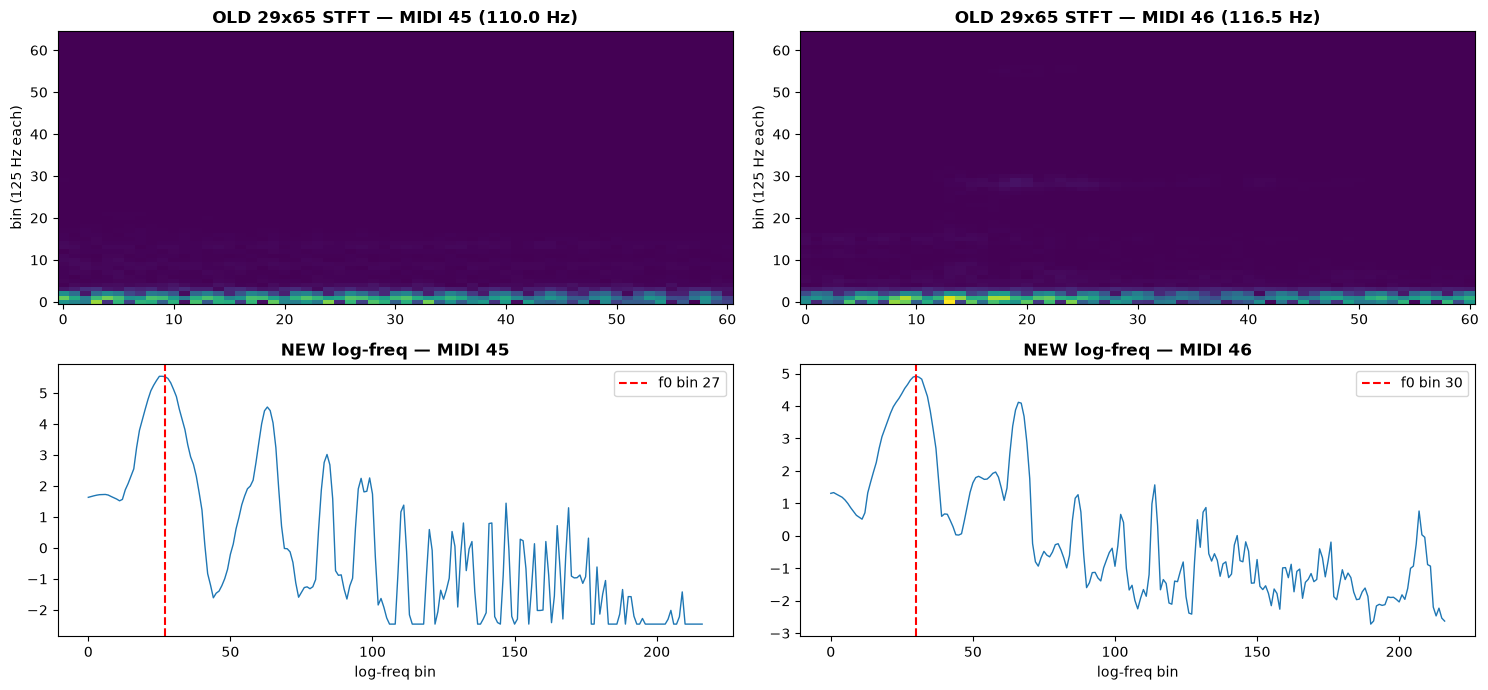

MIDI 45 vs 46 relative distance
  old features : 0.5067
  log-frequency: 0.5943   (1.2x further apart)


In [11]:
def old_features_np(x):
    """The previous representation, for comparison only."""
    L, S = 128, 32
    w = 0.5 - 0.5 * np.cos(2 * np.pi * np.arange(L) / L)
    fr = np.stack([x[i * S:i * S + L] * w for i in range(1 + (AUDIO_LENGTH - L) // S)])
    return np.abs(np.fft.rfft(fr, n=128, axis=-1)).astype(np.float32)


# Pick two adjacent numeric classes that both exist in the training set.
numeric = sorted(int(c) for c in class_names if c.isdigit())
pair = next(((a, a + 1) for a in numeric if a + 1 in numeric), None)
assert pair, "no adjacent pair found"

def first_path(midi):
    tgt = str(midi)
    return next(p for p, l in zip(train_paths, train_labels_str) if l == tgt)

waves, olds, news = [], [], []
for m in pair:
    aud, _ = load_audio(tf.constant(first_path(m)), 0)
    aud = aud.numpy()
    waves.append(aud)
    olds.append(old_features_np(aud))
    news.append(get_features(tf.constant(aud), 0)[0].numpy().squeeze())

fig, axes = plt.subplots(2, 2, figsize=(15, 7))
vmax = max(o.max() for o in olds)
for j, m in enumerate(pair):
    axes[0, j].imshow(olds[j].T, aspect='auto', origin='lower', vmax=vmax)
    axes[0, j].set_title(f"OLD 29x65 STFT — MIDI {m} ({midi_to_hz(m):.1f} Hz)",
                         fontweight='bold')
    axes[0, j].set_ylabel("bin (125 Hz each)")

for j, m in enumerate(pair):
    axes[1, j].plot(news[j], lw=1)
    axes[1, j].axvline((m - MIDI_LOW) * BINS_PER_SEMI, color='r', ls='--',
                       label=f'f0 bin {(m - MIDI_LOW) * BINS_PER_SEMI}')
    axes[1, j].set_title(f"NEW log-freq — MIDI {m}", fontweight='bold')
    axes[1, j].set_xlabel("log-freq bin"); axes[1, j].legend()
plt.tight_layout(); plt.show()

d_old = np.linalg.norm(olds[0] - olds[1]) / (np.linalg.norm(olds[0]) + 1e-9)
d_new = np.linalg.norm(news[0] - news[1]) / (np.linalg.norm(news[0]) + 1e-9)
print(f"MIDI {pair[0]} vs {pair[1]} relative distance")
print(f"  old features : {d_old:.4f}")
print(f"  log-frequency: {d_new:.4f}   ({d_new / max(d_old, 1e-9):.1f}x further apart)")

## 6. Models

### Why these shapes

Kernels are `(21, 1)` — tall along frequency, width 1. 21 bins is 7 semitones,
wide enough to capture the local shape around a harmonic peak.

Exactly **one** `MaxPooling2D((2, 1))`, and no more. Pooling along the frequency
axis directly discards pitch precision: after one pool there are 1.5 bins per
semitone, which still separates adjacent notes. A second pool would drop to 0.75
bins per semitone and adjacent semitones would start landing in the same
position. This is the opposite of the usual image-CNN instinct and it is the
single easiest thing to get wrong here.

Stacking two `(21,1)` convs after the pool gives a receptive field of ~101 input
bins ≈ 2.8 octaves, enough to see harmonics 1–7 together — which is exactly the
range the resolvability table said carries the information.

The `(1,1)` conv before the Flatten squeezes channels so the final Dense stays
small. That layer was 7168→32 = 229k parameters in the old model; here it is
432→33 = 14k.

In [12]:
def build_teacher(input_shape, num_classes):
    return models.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv2D(24, (21, 1), padding='same', activation='relu'),
        layers.MaxPooling2D((2, 1)),                  # ONE pool only
        layers.Conv2D(32, (21, 1), padding='same', activation='relu'),
        layers.Dropout(0.2),
        layers.Conv2D(32, (21, 1), padding='same', activation='relu'),
        layers.Conv2D(8, (1, 1), activation='relu'),  # channel squeeze
        layers.Flatten(),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax'),
    ], name="teacher")


teacher_model = build_teacher(input_shape, num_classes)
teacher_model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy'])
teacher_model.summary()

Model: "teacher"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 217, 1, 24)        528       
                                                                 
 max_pooling2d (MaxPooling2  (None, 108, 1, 24)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 108, 1, 32)        16160     
                                                                 
 dropout (Dropout)           (None, 108, 1, 32)        0         
                                                                 
 conv2d_2 (Conv2D)           (None, 108, 1, 32)        21536     
                                                                 
 conv2d_3 (Conv2D)           (None, 108, 1, 8)         264       
                                                           

In [13]:
EPOCHS = 25
history = teacher_model.fit(
    train_ds, validation_data=val_ds, epochs=EPOCHS,
    class_weight=class_weight,
    callbacks=[keras.callbacks.EarlyStopping(
        monitor='val_accuracy', mode='max', patience=6,
        restore_best_weights=True)])

Epoch 1/25


E0000 00:00:1786677185.612364    4470 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inteacher/dropout/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1786677185.877922    4580 cuda_dnn.cc:461] Loaded cuDNN version 92400
I0000 00:00:1786677187.451270    4579 service.cc:153] XLA service 0x74af647cf4a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1786677187.451373    4579 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3050 Ti Laptop GPU, Compute Capability 8.6 (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.24.0)
I0000 00:00:1786677187.468958    4579 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1786677187.583147    4579 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1002/1002 [==============================] - 10s 7ms/step - loss: 0.3674 - accuracy: 0.9368 - val_loss: 0.5508 - val_accuracy: 0.8064
Epoch 2/25
1002/1002 [==============================] - 6s 6ms/step - loss: 0.1248 - accuracy: 0.9764 - val_loss: 0.2608 - val_accuracy: 0.9259
Epoch 3/25
1002/1002 [==============================] - 4s 3ms/step - loss: 0.1001 - accuracy: 0.9783 - val_loss: 0.1897 - val_accuracy: 0.9481
Epoch 4/25
1002/1002 [==============================] - 6s 6ms/step - loss: 0.0951 - accuracy: 0.9805 - val_loss: 0.2390 - val_accuracy: 0.9366
Epoch 5/25
1002/1002 [==============================] - 7s 6ms/step - loss: 0.0853 - accuracy: 0.9804 - val_loss: 0.2134 - val_accuracy: 0.9472
Epoch 6/25
1002/1002 [==============================] - 7s 7ms/step - loss: 0.0807 - accuracy: 0.9809 - val_loss: 0.2091 - val_accuracy: 0.9446
Epoch 7/25
1002/1002 [==============================] - 7s 7ms/step - loss: 0.0755 - accuracy: 0.9824 - val_loss: 0.3195 - val_accuracy: 0.9161
Ep

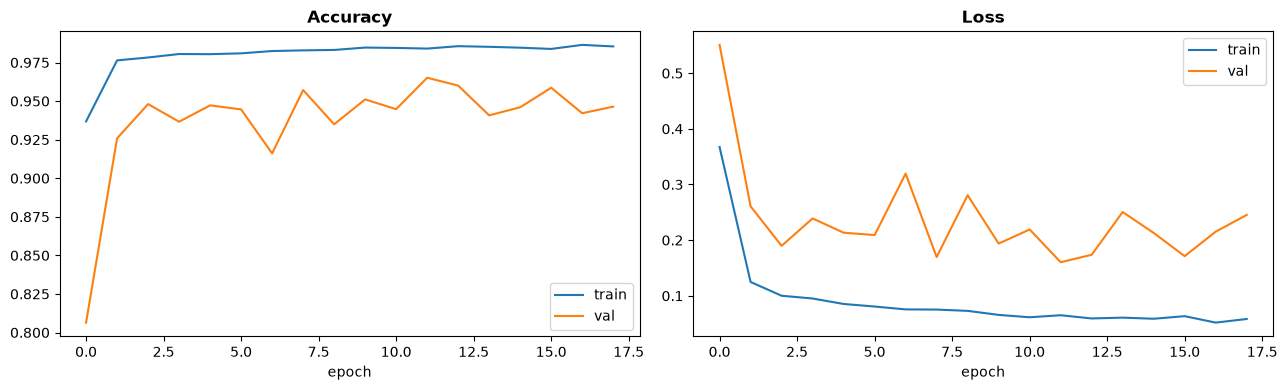

best val accuracy: 96.51%


In [14]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4))
a1.plot(history.history['accuracy'], label='train')
a1.plot(history.history['val_accuracy'], label='val')
a1.set_title('Accuracy', fontweight='bold'); a1.set_xlabel('epoch'); a1.legend()
a2.plot(history.history['loss'], label='train')
a2.plot(history.history['val_loss'], label='val')
a2.set_title('Loss', fontweight='bold'); a2.set_xlabel('epoch'); a2.legend()
plt.tight_layout(); plt.show()

print(f"best val accuracy: {max(history.history['val_accuracy']) * 100:.2f}%")

## 7. Compression: distillation → pruning → INT8

Same three-stage pipeline as the original project, applied to the new
architecture.

### 7a. Knowledge distillation

In [15]:
def build_student(input_shape, num_classes):
    return keras.Sequential([
        keras.layers.InputLayer(input_shape=input_shape),
        keras.layers.Conv2D(12, (21, 1), padding='same', activation='relu'),
        keras.layers.MaxPooling2D((2, 1)),
        keras.layers.Conv2D(16, (21, 1), padding='same', activation='relu'),
        keras.layers.Conv2D(16, (21, 1), padding='same', activation='relu'),
        keras.layers.Conv2D(4, (1, 1), activation='relu'),
        keras.layers.Flatten(),
        keras.layers.Dense(num_classes, activation='softmax'),
    ], name="student")


student_model = build_student(input_shape, num_classes)
student_model.summary()


class Distiller(keras.Model):
    def __init__(self, student, teacher):
        super().__init__()
        self.teacher = teacher
        self.student = student

    def compile(self, optimizer, metrics, student_loss_fn,
                distillation_loss_fn, alpha=0.3, temperature=4.0):
        super().compile(optimizer=optimizer, metrics=metrics)
        self.student_loss_fn = student_loss_fn
        self.distillation_loss_fn = distillation_loss_fn
        self.alpha = alpha
        self.temperature = temperature

    def call(self, x):
        return self.student(x)

    def train_step(self, data):
        x, y = data
        teacher_predictions = self.teacher(x, training=False)
        with tf.GradientTape() as tape:
            student_predictions = self.student(x, training=True)
            student_loss = self.student_loss_fn(y, student_predictions)
            distillation_loss = self.distillation_loss_fn(
                tf.nn.softmax(teacher_predictions / self.temperature, axis=1),
                tf.nn.softmax(student_predictions / self.temperature, axis=1),
            ) * (self.temperature ** 2)
            loss = self.alpha * student_loss + (1.0 - self.alpha) * distillation_loss
        grads = tape.gradient(loss, self.student.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.student.trainable_variables))
        self.compiled_metrics.update_state(y, student_predictions)
        return {m.name: m.result() for m in self.metrics}

    def test_step(self, data):
        x, y = data
        pred = self.student(x, training=False)
        self.compiled_metrics.update_state(y, pred)
        results = {m.name: m.result() for m in self.metrics}
        results.update({"student_loss": self.student_loss_fn(y, pred)})
        return results


distiller = Distiller(student=student_model, teacher=teacher_model)
distiller.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    metrics=[keras.metrics.SparseCategoricalAccuracy(name="accuracy")],
    student_loss_fn=keras.losses.SparseCategoricalCrossentropy(),
    distillation_loss_fn=keras.losses.KLDivergence(),
    alpha=0.3, temperature=4.0)

distiller.fit(train_ds, epochs=25, validation_data=val_ds)
student_model.save_weights("distilled_student.weights.h5")

Model: "student"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_4 (Conv2D)           (None, 217, 1, 12)        264       
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 108, 1, 12)        0         
 g2D)                                                            
                                                                 
 conv2d_5 (Conv2D)           (None, 108, 1, 16)        4048      
                                                                 
 conv2d_6 (Conv2D)           (None, 108, 1, 16)        5392      
                                                                 
 conv2d_7 (Conv2D)           (None, 108, 1, 4)         68        
                                                                 
 flatten_1 (Flatten)         (None, 432)               0         
                                                           

### 7b. Magnitude-based pruning

In [16]:
from tensorflow_model_optimization.sparsity.keras import (
    prune_low_magnitude, PolynomialDecay, UpdatePruningStep, strip_pruning)

epochs_for_pruning = 10
warmup_epochs      = 2
steps_per_epoch    = tf.data.experimental.cardinality(train_ds).numpy()

pruning_params = {"pruning_schedule": PolynomialDecay(
    initial_sparsity=0.0, final_sparsity=0.50,
    begin_step=steps_per_epoch * warmup_epochs,
    end_step=steps_per_epoch * epochs_for_pruning)}


def apply_pruning_to_layer(layer):
    if isinstance(layer, (keras.layers.Dense, keras.layers.Conv2D)):
        return prune_low_magnitude(layer, **pruning_params)
    return layer


pruned_model = keras.models.clone_model(
    student_model, clone_function=apply_pruning_to_layer)

for orig, pruned in zip(student_model.layers, pruned_model.layers):
    if hasattr(pruned, 'layer'):
        pruned.layer.set_weights(orig.get_weights())
    else:
        pruned.set_weights(orig.get_weights())

pruned_model.compile(optimizer=keras.optimizers.Adam(5e-5),
                     loss="sparse_categorical_crossentropy",
                     metrics=["accuracy"])

pruned_model.fit(train_ds, validation_data=val_ds,
                 epochs=epochs_for_pruning + 10,
                 class_weight=class_weight,
                 callbacks=[UpdatePruningStep()])

stripped_sparse_model = strip_pruning(pruned_model)
print("Pruning wrappers stripped.")

Epoch 1/20
1002/1002 [==============================] - 14s 13ms/step - loss: 0.0891 - accuracy: 0.9788 - val_loss: 0.2135 - val_accuracy: 0.9603
Epoch 2/20
1002/1002 [==============================] - 15s 14ms/step - loss: 0.0503 - accuracy: 0.9876 - val_loss: 0.2289 - val_accuracy: 0.9584
Epoch 3/20
1002/1002 [==============================] - 10s 10ms/step - loss: 0.0407 - accuracy: 0.9886 - val_loss: 0.2188 - val_accuracy: 0.9599
Epoch 4/20
1002/1002 [==============================] - 15s 15ms/step - loss: 0.0431 - accuracy: 0.9881 - val_loss: 0.2064 - val_accuracy: 0.9554
Epoch 5/20
1002/1002 [==============================] - 12s 12ms/step - loss: 0.0470 - accuracy: 0.9868 - val_loss: 0.1891 - val_accuracy: 0.9606
Epoch 6/20
1002/1002 [==============================] - 14s 14ms/step - loss: 0.0513 - accuracy: 0.9854 - val_loss: 0.1916 - val_accuracy: 0.9614
Epoch 7/20
1002/1002 [==============================] - 10s 10ms/step - loss: 0.0515 - accuracy: 0.9853 - val_loss: 0.2144 -

### 7c. INT8 quantization

`tf.lite.Optimize.EXPERIMENTAL_SPARSITY` is deliberately **absent**. It emits a
compressed sparse-tensor encoding that TFLM's kernels do not decode — the
interpreter either refuses to allocate or produces garbage. Plain
`Optimize.DEFAULT` is what goes on the board.

In [17]:
def representative_data_gen():
    for xb, _ in train_ds.take(20):
        for x in xb:
            yield [tf.expand_dims(tf.cast(x, tf.float32), axis=0)]


converter = tf.lite.TFLiteConverter.from_keras_model(stripped_sparse_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]      # NO sparsity flag
converter.representative_dataset = representative_data_gen
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type  = tf.int8
converter.inference_output_type = tf.int8

deploy_tflite = converter.convert()
DEPLOY_PATH = "midi_note_logfreq_int8.tflite"
with open(DEPLOY_PATH, "wb") as f:
    f.write(deploy_tflite)

interp = tf.lite.Interpreter(model_path=DEPLOY_PATH)
interp.allocate_tensors()
in_det, out_det = interp.get_input_details()[0], interp.get_output_details()[0]
in_scale,  in_zp  = in_det["quantization"]
out_scale, out_zp = out_det["quantization"]

print(f"model size  : {len(deploy_tflite) / 1024:.1f} KB")
print(f"input       : {in_det['shape']}  scale {in_scale:.8f}  zp {in_zp}")
print(f"output      : {out_det['shape']}  scale {out_scale:.8f}  zp {out_zp}")

INFO:tensorflow:Assets written to: /tmp/tmp9xzs0c1o/assets


INFO:tensorflow:Assets written to: /tmp/tmp9xzs0c1o/assets
/home/zachh/ai/projects/tinyml-arduino/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:846: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
W0000 00:00:1786677775.332768    4470 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1786677775.332818    4470 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1786677775.333129    4470 reader.cc:83] Reading SavedModel from: /tmp/tmp9xzs0c1o
I0000 00:00:1786677775.333964    4470 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1786677775.333971    4470 reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmp9xzs0c1o
I0000 00:00:1786677775.340894    4470 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled
I0000 00:00:1786677775.341560    4470 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:17866

model size  : 27.8 KB
input       : [  1 217   1   1]  scale 0.03934528  zp -39
output      : [ 1 28]  scale 0.00390625  zp -128


fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8
W0000 00:00:1786677776.507527    4470 flatbuffer_export.cc:3851] Skipping runtime version metadata in the model. This will be generated by the exporter.
/home/zachh/ai/projects/tinyml-arduino/lib/python3.11/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


In [18]:
# Confirm only the five ops the ESP32 sketch registers are present.
tf.lite.experimental.Analyzer.analyze(model_content=deploy_tflite)

=== TFLite ModelAnalyzer ===

Your TFLite model has '1' subgraph(s). In the subgraph description below,
T# represents the Tensor numbers. For example, in Subgraph#0, the CONV_2D op takes
tensor #0 and tensor #11 and tensor #10 as input and produces tensor #12 as output.

Subgraph#0 main(T#0) -> [T#19]
  Op#0 CONV_2D(T#0, T#11, T#10[-4011, -1022, -1568, -1603, -1959, ...]) -> [T#12]
  Op#1 MAX_POOL_2D(T#12) -> [T#13]
  Op#2 CONV_2D(T#13, T#9, T#8[130, 395, 280, 949, 1156, ...]) -> [T#14]
  Op#3 CONV_2D(T#14, T#7, T#6[-402, 1334, 407, 837, -306, ...]) -> [T#15]
  Op#4 CONV_2D(T#15, T#5, T#4[454, 363, 141, 410]) -> [T#16]
  Op#5 RESHAPE(T#16, T#1[-1, 432]) -> [T#17]
  Op#6 FULLY_CONNECTED(T#17, T#3, T#2[-127, -160, -238, -250, -186, ...]) -> [T#18]
  Op#7 SOFTMAX(T#18) -> [T#19]

Tensors of Subgraph#0
  T#0(serving_default_input_2:0) shape_signature:[-1, 217, 1, 1], type:INT8
  T#1(arith.constant) shape:[2], type:INT32 RO 8 bytes, buffer: 2, data:[-1, 432]
  T#2(student/dense_1/BiasAdd) s

## 8. Evaluation and comparison

In [19]:
import pandas as pd


def keras_size_kb(model, path="_tmp.h5"):
    model.save(path)
    kb = os.path.getsize(path) / 1024
    os.remove(path)
    return kb


def keras_acc(model, ds):
    correct = total = 0
    for xb, yb in ds:
        p = np.argmax(model.predict(xb, verbose=0), axis=1)
        correct += int((p == yb.numpy()).sum()); total += len(yb)
    return correct / total


def tflite_acc(path, ds):
    it = tf.lite.Interpreter(model_path=path); it.allocate_tensors()
    i_d, o_d = it.get_input_details()[0], it.get_output_details()[0]
    s, z = i_d["quantization"]
    correct = total = 0
    for xb, yb in ds:
        for x, y in zip(xb.numpy(), yb.numpy()):
            q = np.clip(np.round(x / s + z), -128, 127).astype(i_d["dtype"])
            it.set_tensor(i_d["index"], np.expand_dims(q, 0)); it.invoke()
            correct += int(np.argmax(it.get_tensor(o_d["index"])[0]) == y); total += 1
    return correct / total


rows = [
    ("Teacher (log-freq CNN)",       keras_size_kb(teacher_model),         keras_acc(teacher_model, test_ds)),
    ("Student (distilled)",          keras_size_kb(student_model),         keras_acc(student_model, test_ds)),
    ("Student (pruned, float)",      keras_size_kb(stripped_sparse_model), keras_acc(stripped_sparse_model, test_ds)),
    ("Student (pruned + INT8)",      os.path.getsize(DEPLOY_PATH) / 1024,  tflite_acc(DEPLOY_PATH, test_ds)),
]
comparison_df = pd.DataFrame(rows, columns=["Model", "Size (KB)", "Test Accuracy"])
comparison_df["Size (KB)"]        = comparison_df["Size (KB)"].round(1)
comparison_df["Test Accuracy (%)"] = (comparison_df["Test Accuracy"] * 100).round(2)
comparison_df = comparison_df.drop(columns=["Test Accuracy"])
comparison_df

/home/zachh/ai/projects/tinyml-arduino/lib/python3.11/site-packages/tf_keras/src/engine/training.py:3098: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native TF-Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


,Model,Size (KB),Test Accuracy (%)
0,Teacher (log-freq CNN),786.4,95.85
1,Student (distilled),112.6,94.20
2,"Student (pruned, float)",112.6,94.20
3,Student (pruned + INT8),27.8,93.87


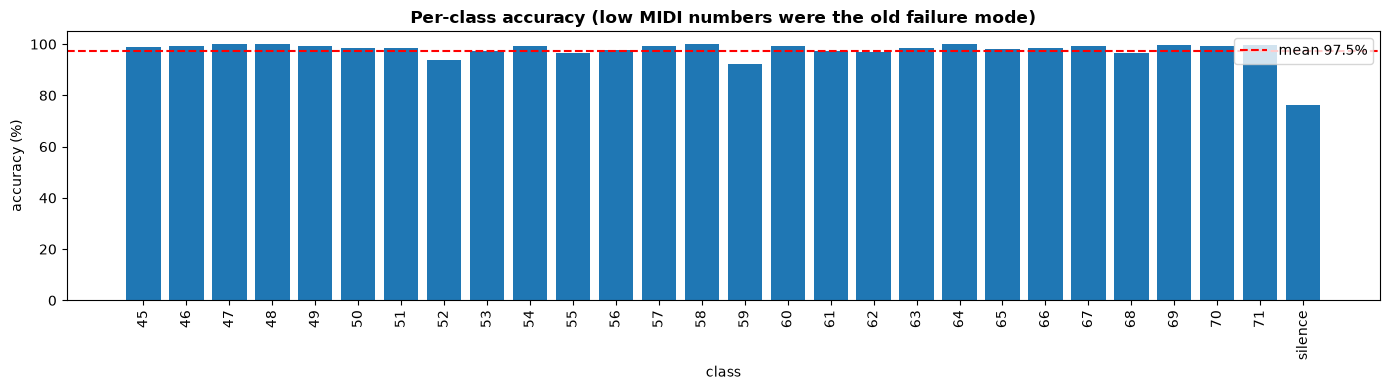

In [20]:
# Per-class accuracy. The old representation failed hardest on LOW notes,
# where the fundamental was unresolvable -- check that the floor has lifted.
y_true, y_pred = [], []
for xb, yb in test_ds:
    y_pred.extend(np.argmax(student_model.predict(xb, verbose=0), axis=1))
    y_true.extend(yb.numpy())
y_true, y_pred = np.array(y_true), np.array(y_pred)

per_class = [( (y_pred[y_true == i] == i).mean() if (y_true == i).any() else np.nan)
             for i in range(num_classes)]

plt.figure(figsize=(14, 4))
plt.bar(range(num_classes), np.array(per_class) * 100)
plt.xticks(range(num_classes), class_names, rotation=90)
plt.ylabel("accuracy (%)"); plt.xlabel("class")
plt.title("Per-class accuracy (low MIDI numbers were the old failure mode)",
          fontweight='bold')
plt.axhline(np.nanmean(per_class) * 100, color='r', ls='--',
            label=f'mean {np.nanmean(per_class) * 100:.1f}%')
plt.legend(); plt.tight_layout(); plt.show()

## 9. Export the C headers

Writes four files for the `midi_note_esp32/` sketch folder:

| file | contents |
|---|---|
| `model.h` | the INT8 model bytes, 16-byte aligned |
| `model_params.h` | geometry, labels, quantization reference |
| `filterbank.h` | the 217 triangular filters, sparse |
| `golden_test.h` | one real clip + expected features + expected output |

The filterbank is stored sparsely (start index + run of weights per bin) because
it is only ~0.5% dense — storing it as a full 217×1025 matrix would be 890 KB.

In [21]:
from pathlib import Path


def c_array(name, data, per_line=12, fmt="0x{:02x}", ctype="unsigned char",
            prefix=""):
    lines = [f"{prefix}const {ctype} {name}[] = {{"]
    for i in range(0, len(data), per_line):
        lines.append("  " + ", ".join(fmt.format(v) for v in data[i:i + per_line]) + ",")
    lines.append("};")
    lines.append(f"const unsigned int {name}_len = {len(data)};")
    return "\n".join(lines)


# ---- model.h --------------------------------------------------------------
Path("model.h").write_text("\n".join([
    "// AUTO-GENERATED. Do not edit.",
    "#pragma once",
    "",
    "// alignas(16): TFLM reads the FlatBuffer in place and requires 16-byte",
    "// alignment. Without it GetModel() may fault or silently misparse.",
    c_array("g_model", Path(DEPLOY_PATH).read_bytes(), prefix="alignas(16) "),
    "",
]), encoding="utf-8")

# ---- filterbank.h ---------------------------------------------------------
starts, lengths, weights = [], [], []
for i in range(N_LOG_BINS):
    nz = np.nonzero(FILTERBANK[i])[0]
    starts.append(int(nz[0]))
    lengths.append(int(nz[-1] - nz[0] + 1))
    weights.extend(FILTERBANK[i, nz[0]:nz[-1] + 1].tolist())

Path("filterbank.h").write_text("\n".join([
    "// AUTO-GENERATED. Do not edit.",
    "// Sparse log-frequency triangular filterbank.",
    "// Bin i accumulates kFbWeights[offset_i ...] against",
    "// magnitude[kFbStart[i] ... kFbStart[i]+kFbLength[i]-1], where offset_i",
    "// is the running sum of kFbLength[0..i-1].",
    "#pragma once",
    "",
    c_array("kFbStart",  starts,  per_line=16, fmt="{}", ctype="unsigned short"),
    "",
    c_array("kFbLength", lengths, per_line=16, fmt="{}", ctype="unsigned short"),
    "",
    c_array("kFbWeights", weights, per_line=8, fmt="{:.8f}f", ctype="float"),
    "",
]), encoding="utf-8")

# ---- model_params.h -------------------------------------------------------
labels_c = ",\n".join(f'  "{c}"' for c in class_names)
Path("model_params.h").write_text(f"""// AUTO-GENERATED. Do not edit.
#pragma once

// ---- audio front end -----------------------------------------------------
constexpr int   kSampleRate    = {SAMPLE_RATE};
constexpr int   kWindowSamples = {AUDIO_LENGTH};   // 64 ms
constexpr int   kFFTSize       = {FFT_SIZE};       // zero-padded from kWindowSamples
constexpr int   kNumFFTBins    = {FFT_SIZE // 2 + 1};
constexpr int   kNumLogBins    = {N_LOG_BINS};
constexpr float kLogEps        = {LOG_EPS}f;
constexpr float kLogTopRange   = {LOG_TOP_RANGE}f;

// Model input is (kNumLogBins, 1, 1).
constexpr int kFeatureElements = {N_LOG_BINS};

// ---- filterbank geometry (informational) ---------------------------------
constexpr int kMidiLow      = {MIDI_LOW};
constexpr int kMidiHigh     = {MIDI_HIGH};
constexpr int kBinsPerSemi  = {BINS_PER_SEMI};

// ---- model ---------------------------------------------------------------
constexpr int kCategoryCount = {num_classes};

constexpr float kRefInputScale  = {in_scale:.10f}f;
constexpr int   kRefInputZero   = {in_zp};
constexpr float kRefOutputScale = {out_scale:.10f}f;
constexpr int   kRefOutputZero  = {out_zp};

inline const char* const kCategoryLabels[kCategoryCount] = {{
{labels_c}
}};

constexpr int kSilenceIndex = {class_names.index('silence') if 'silence' in class_names else -1};
""", encoding="utf-8")

# ---- golden_test.h --------------------------------------------------------
golden_audio = golden_label = None
for xb, yb in test_raw.map(load_audio).batch(64).take(20):
    for a, l in zip(xb.numpy(), yb.numpy()):
        if class_names[int(l)] != "silence" and np.abs(a).max() > 1e-3:
            golden_audio, golden_label = a, int(l)
            break
    if golden_audio is not None:
        break
assert golden_audio is not None, "no usable non-silence test clip found"

golden_feat = get_features(tf.constant(golden_audio), 0)[0].numpy().squeeze()
q = np.clip(np.round(golden_feat.reshape(N_LOG_BINS, 1, 1) / in_scale + in_zp),
            -128, 127).astype(np.int8)[None, ...]
interp.set_tensor(in_det["index"], q); interp.invoke()
golden_out = interp.get_tensor(out_det["index"])[0]

Path("golden_test.h").write_text("\n".join([
    "// AUTO-GENERATED. Do not edit.",
    f"// True label: {class_names[golden_label]}",
    "#pragma once",
    "",
    f"constexpr int kGoldenLabelIndex = {golden_label};",
    "",
    "// Raw waveform as tf.audio.decode_wav produced it.",
    c_array("kGoldenAudio", golden_audio.tolist(), per_line=8,
            fmt="{:.8f}f", ctype="float"),
    "",
    "// Expected log-frequency features (post log, post mean-subtraction).",
    c_array("kGoldenFeatures", golden_feat.tolist(), per_line=8,
            fmt="{:.8f}f", ctype="float"),
    "",
    "// Desktop TFLite output for the quantized golden features.",
    c_array("kGoldenOutput", golden_out.tolist(), per_line=16,
            fmt="{}", ctype="signed char"),
    "",
]), encoding="utf-8")

for f in ("model.h", "model_params.h", "filterbank.h", "golden_test.h"):
    print(f"{f:18s} {Path(f).stat().st_size / 1024:8.1f} KB")

print(f"\ngolden clip: true={class_names[golden_label]}  "
      f"predicted={class_names[int(np.argmax(golden_out))]}")

model.h               171.6 KB
model_params.h          1.3 KB
filterbank.h           18.6 KB
golden_test.h          30.9 KB

golden clip: true=45  predicted=45


In [22]:
try:
    from google.colab import files
    for f in ("model.h", "model_params.h", "filterbank.h", "golden_test.h",
              DEPLOY_PATH):
        files.download(f)
except ImportError:
    print("Not on Colab -- files are in the working directory.")

print("\nCopy the four .h files into midi_note_esp32/ and rebuild.")

Not on Colab -- files are in the working directory.

Copy the four .h files into midi_note_esp32/ and rebuild.


## 10. Firmware notes

The sketch needs three changes to match this front end. Updated
`feature_provider.cpp` and `fft.h` are supplied alongside this notebook.

1. **`fft.h`** — raise `kFFTMaxSize` from 1024 to 2048.
2. **`feature_provider.cpp`** — replace the 29-frame STFT loop with: one
   2048-point zero-padded FFT over the whole window, the sparse filterbank
   accumulation, `logf`, then mean subtraction.
3. **`midi_note_esp32.ino`** — the golden test now compares against
   `kGoldenFeatures` rather than `kGoldenSpec`.

Two things get *easier*:

- **`kMicGain` no longer matters much.** The features are gain-invariant, so
  the calibration step in the README drops from mandatory to a sanity check.
  Keep the RMS gate — it still stops the recognizer chewing on room noise.
- **Compute drops.** 29 128-point FFTs become one 2048-point FFT, and the model
  is ~10x smaller. Expect the tensor arena to fall to roughly 25 KB, and
  `kHopSamples` could go to 256 (16 ms) if you want faster response.